### Imbalanced dataset
It refers to a majority of data points being the same value so if we train with these data then the model majority output would be the same which would result in having an inconsistent models to overcome this we have multiple sampling techniques
are :
Oversampling
UnderSampling

Based on the datapoints we cna oversample the data or undersample the data but by undersampling the data we might lose some the important feature which would also relatively impact the models performance.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df= pd.read_csv("/content/Insurance claims data.csv")
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [4]:
df.shape

(58592, 41)

In [8]:
df.isnull().sum()

,0
policy_id,0
subscription_length,0
vehicle_age,0
customer_age,0
region_code,0
region_density,0
segment,0
model,0
fuel_type,0
max_torque,0


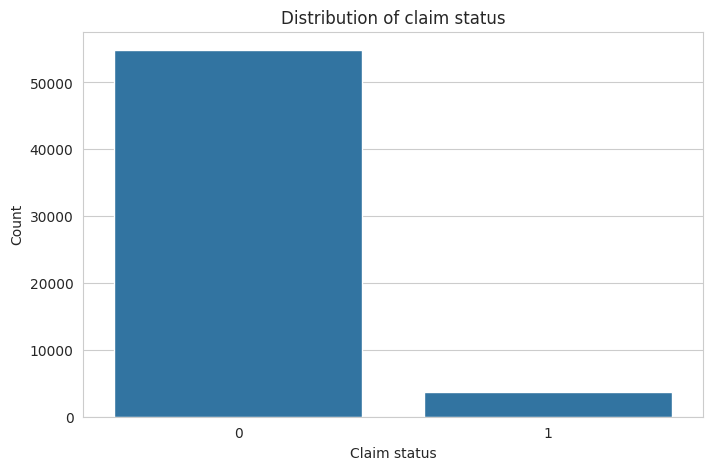

In [10]:
## exploratory data analysis

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
sns.countplot(x='claim_status', data=df)
plt.xlabel("Claim status")
plt.ylabel("Count")
plt.title("Distribution of claim status")
plt.show()

In [11]:
df["claim_status"].value_counts()

,count
claim_status,
0,54844
1,3748


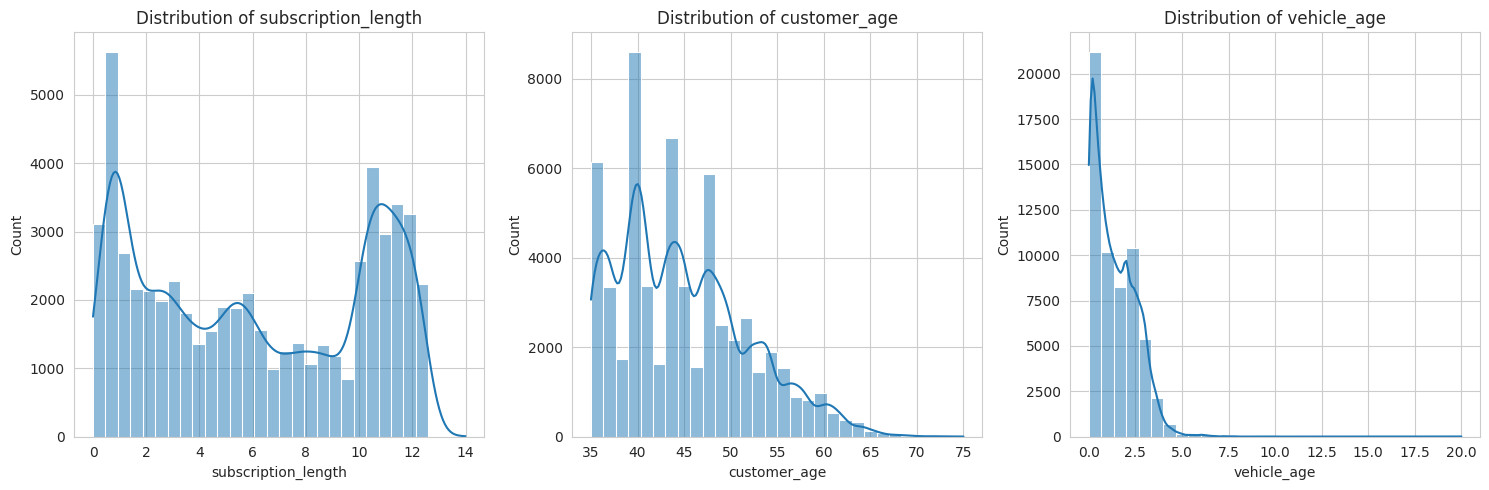

In [13]:
## select the numerical columns for
num_cols= ['subscription_length','customer_age','vehicle_age']

## plot the distributions
plt.figure(figsize=(15,5))
for i, cols in enumerate(num_cols,1):
  plt.subplot(1,3,i)
  sns.histplot(df[cols], bins=30, kde=True)
  plt.title(f"Distribution of {cols}")

plt.tight_layout()
plt.show()

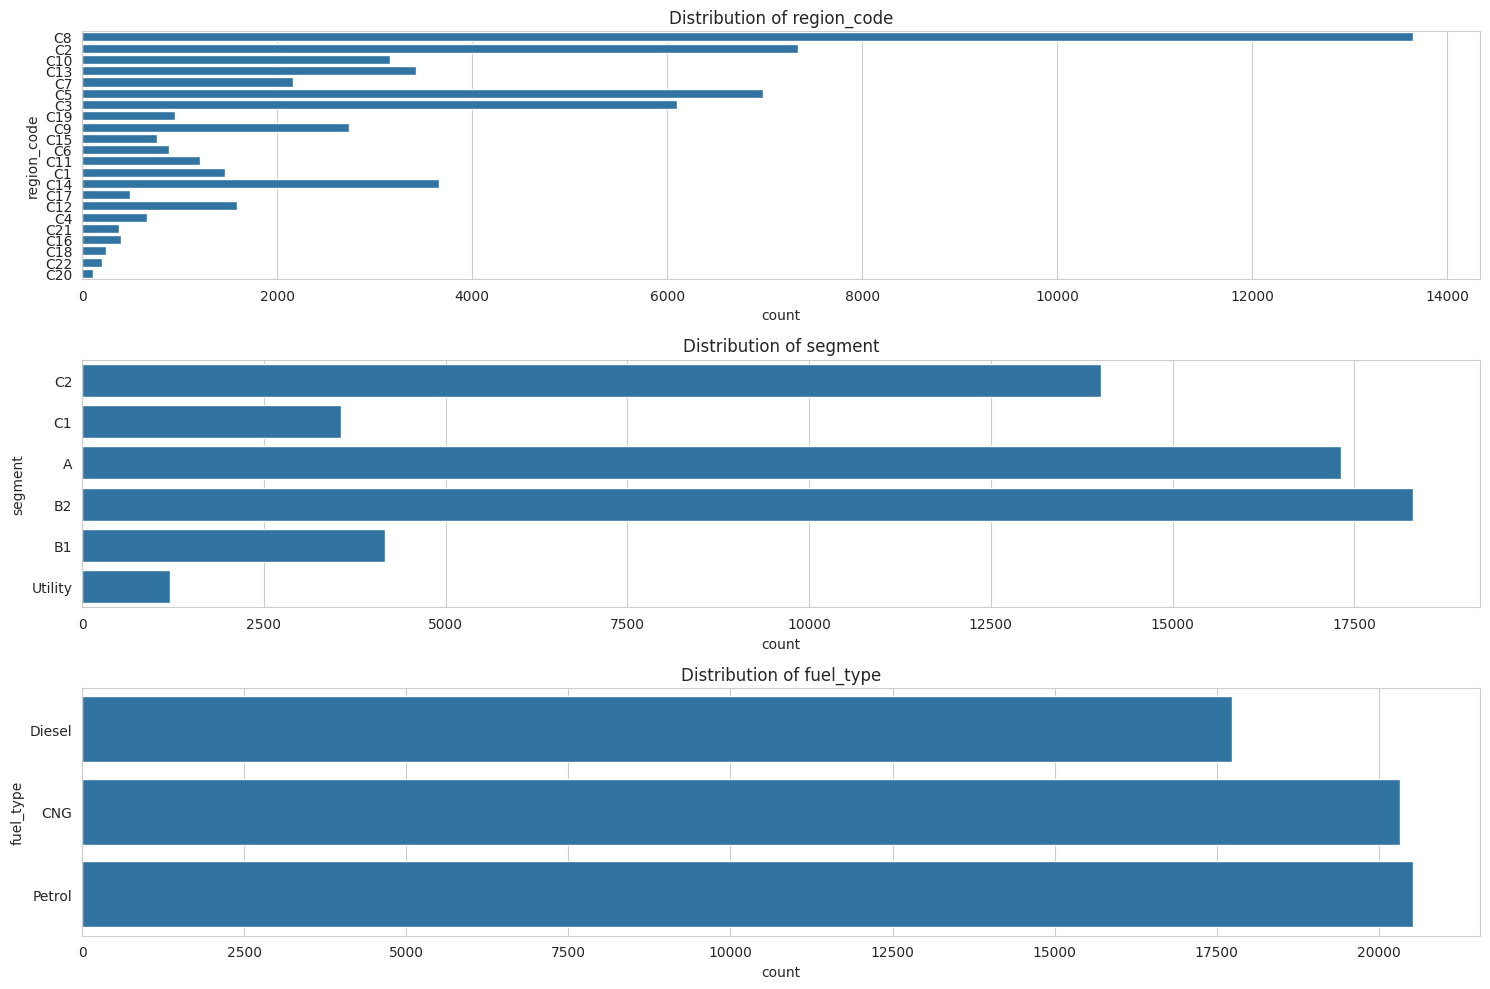

In [28]:
cat_cols= ['region_code','segment','fuel_type']
## plot the distributions
plt.figure(figsize=(15,10))
for i, cols in enumerate(cat_cols,1):
  plt.subplot(3,1,i)
  order= df[cols].value_counts()
  sns.countplot(y=cols,data=df)
  plt.title(f"Distribution of {cols}")
  plt.xlabel('count')
  plt.ylabel(cols)

plt.tight_layout()
plt.show()

In [29]:
## Handling the imbalanced dataset
from sklearn.utils import resample
majority= df[df.claim_status==0]
minority= df[df.claim_status==1]

## oversample the minority class
minority_oversampled= resample(minority, replace=True, n_samples=len(majority), random_state=42)

oversampled_data= pd.concat([majority, minority_oversampled])

oversampled_distribution= oversampled_data.claim_status.value_counts()
oversampled_distribution

,count
claim_status,
0,54844
1,54844


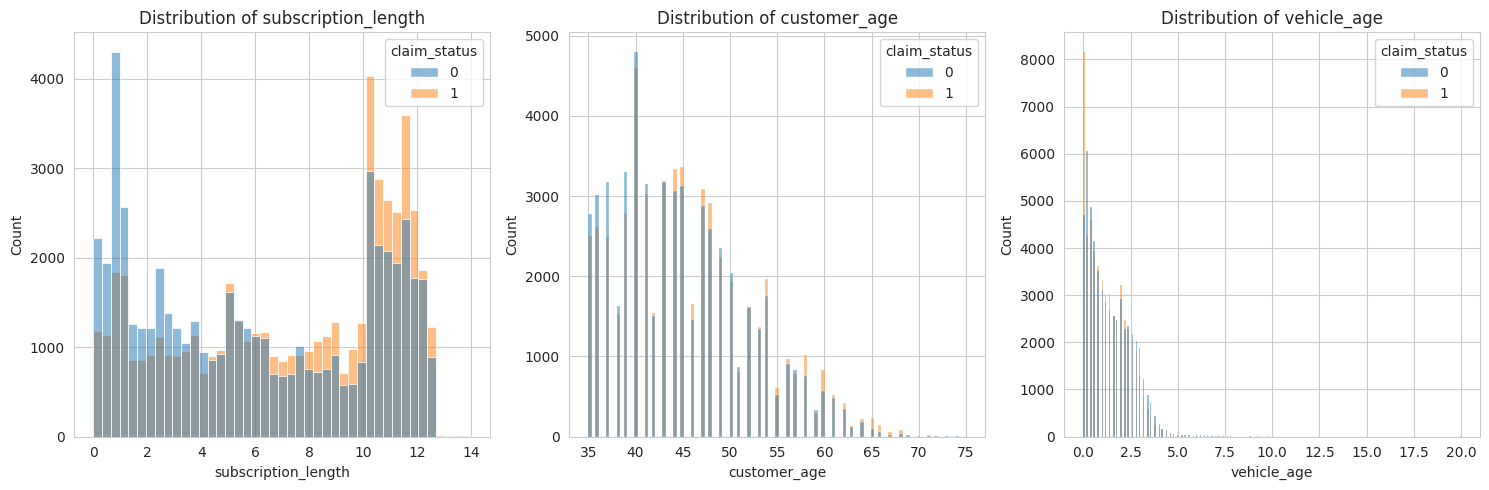

In [31]:
## select the numerical columns for
num_cols= ['subscription_length','customer_age','vehicle_age']

## plot the distributions
plt.figure(figsize=(15,5))
for i, cols in enumerate(num_cols,1):
  plt.subplot(1,3,i)
  sns.histplot(x=cols,data=oversampled_data, hue='claim_status')
  plt.title(f"Distribution of {cols}")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
encoded_data= df.apply(lambda col: le.fit_transform(col) if col.dtype=='object' else col)
encoded_data

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,45359,9.3,1.2,41,20,8794,4,5,1,4,...,1,1,1,1,1,0,1,1,3,0
1,16744,8.2,1.8,35,11,27003,3,10,1,2,...,0,1,1,1,1,1,1,1,4,0
2,7193,9.5,0.2,44,20,8794,4,5,1,4,...,1,1,1,1,1,0,1,1,3,0
3,18145,5.2,0.4,44,1,73430,0,0,0,5,...,0,0,0,1,0,0,0,1,0,0
4,49010,10.1,1.0,56,4,5410,2,6,1,3,...,0,1,1,1,0,0,1,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,19268,10.6,2.6,48,17,34738,2,7,2,0,...,1,1,1,1,1,1,1,1,2,0
58588,1253,2.3,2.2,37,15,4076,4,5,1,4,...,1,1,1,1,1,0,1,1,3,0
58589,19858,6.6,2.2,35,20,8794,2,7,2,0,...,1,1,1,1,1,1,1,1,2,0
58590,14060,4.1,3.6,44,20,8794,2,7,2,0,...,1,1,1,1,1,1,1,1,2,0


In [33]:
x= encoded_data.drop('claim_status', axis=1)
y=encoded_data['claim_status']

## create a random forest model classifer

model= RandomForestClassifier()
model.fit(x,y)

## feature importance

feat_imp= model.feature_importances_

## Create a dataframe for visualization of feature importance
feat_df= pd.DataFrame({'Feature': x.columns,'Importance': feat_imp})
feat_df= feat_df.sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

                Feature  Importance
0             policy_id    0.320372
1   subscription_length    0.247890
3          customer_age    0.170021
2           vehicle_age    0.138057
5        region_density    0.057051
4           region_code    0.055329
7                 model    0.001015
24               length    0.000825
26         gross_weight    0.000794
19         displacement    0.000671


In [34]:
## Model Training

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

oversampled_data= oversampled_data.drop('policy_id',axis=1)
## prepare the oversampled data

X_over= oversampled_data.drop('claim_status',axis=1)
y_over= oversampled_data['claim_status']

X_encoded_over= X_over.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype=='object' else col)

## Split the dataset
X_train,X_test,y_train,y_test= train_test_split(X_encoded_over,y_over,test_size=0.30, random_state=42)

model_rnd= RandomForestClassifier()
model_rnd.fit(X_train,y_train)

y_pred= model_rnd.predict(X_test)

print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))



              precision    recall  f1-score   support

           0       1.00      0.96      0.98     16574
           1       0.96      1.00      0.98     16333

    accuracy                           0.98     32907
   macro avg       0.98      0.98      0.98     32907
weighted avg       0.98      0.98      0.98     32907

0.9773604400279575


In [37]:
original_encoded= df.drop('policy_id',axis=1).copy()
encoders= {col: LabelEncoder().fit(X_over[col]) for col in X_over.select_dtypes(include=['object']).columns}

for col in original_encoded.select_dtypes(include=['object']).columns:
  if col in encoders:
    original_encoded[col]= encoders[col].transform(original_encoded[col])

original_encoded_preds= model_rnd.predict(original_encoded.drop('claim_status',axis=1))

comparision_df= pd.DataFrame({
    'Actual': original_encoded['claim_status'],
    'predicted': original_encoded_preds
})

print(comparision_df.head(10))

   Actual  predicted
0       0          0
1       0          0
2       0          0
3       0          1
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


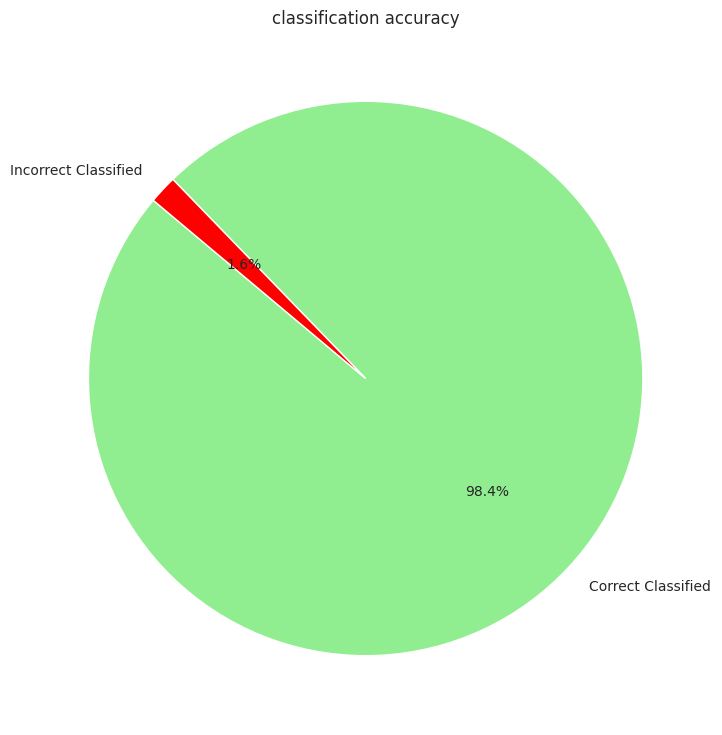

In [44]:
correctly_classified= (comparision_df['Actual'] == comparision_df['predicted']).sum()
incorrectly_classified=(comparision_df['Actual'] != comparision_df['predicted']).sum()

classification_counts= [correctly_classified, incorrectly_classified]

labels= ['Correct Classified', 'Incorrect Classified']

## Create a pie chart

plt.figure(figsize=(9,9))
plt.pie(classification_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightgreen','red'])
plt.title('classification accuracy')
plt.show()

In [45]:
original_encoded= df.drop('policy_id',axis=1).copy()
original_encoded

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,C5,34738,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
58588,2.3,2.2,37,C3,4076,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
58589,6.6,2.2,35,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
58590,4.1,3.6,44,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0


In [46]:
encoders= {col: LabelEncoder().fit(X_over[col]) for col in X_over.select_dtypes(include=['object']).columns}
encoders

{'region_code': LabelEncoder(),
 'segment': LabelEncoder(),
 'model': LabelEncoder(),
 'fuel_type': LabelEncoder(),
 'max_torque': LabelEncoder(),
 'max_power': LabelEncoder(),
 'engine_type': LabelEncoder(),
 'is_esc': LabelEncoder(),
 'is_adjustable_steering': LabelEncoder(),
 'is_tpms': LabelEncoder(),
 'is_parking_sensors': LabelEncoder(),
 'is_parking_camera': LabelEncoder(),
 'rear_brakes_type': LabelEncoder(),
 'transmission_type': LabelEncoder(),
 'steering_type': LabelEncoder(),
 'is_front_fog_lights': LabelEncoder(),
 'is_rear_window_wiper': LabelEncoder(),
 'is_rear_window_washer': LabelEncoder(),
 'is_rear_window_defogger': LabelEncoder(),
 'is_brake_assist': LabelEncoder(),
 'is_power_door_locks': LabelEncoder(),
 'is_central_locking': LabelEncoder(),
 'is_power_steering': LabelEncoder(),
 'is_driver_seat_height_adjustable': LabelEncoder(),
 'is_day_night_rear_view_mirror': LabelEncoder(),
 'is_ecw': LabelEncoder(),
 'is_speed_alert': LabelEncoder()}

In [49]:
for col in original_encoded.select_dtypes(include=['object']).columns:
  if col in encoders:
    print(encoders[col].transform(original_encoded[col]))

[20 11 20 ... 20 20  3]
[4 3 4 ... 2 2 2]
[ 5 10  5 ...  7  7  7]
[1 1 1 ... 2 2 2]
[4 2 4 ... 0 0 0]
[0 8 0 ... 6 6 6]
[ 3 10  3 ...  8  8  8]
[1 0 1 ... 0 0 0]
[1 1 1 ... 1 1 1]
[1 0 1 ... 0 0 0]
[1 1 1 ... 1 1 1]
[1 1 1 ... 0 0 0]
[0 1 0 ... 1 1 1]
[0 1 0 ... 1 1 1]
[2 0 2 ... 0 0 0]
[1 1 1 ... 1 1 1]
[1 0 1 ... 0 0 0]
[1 0 1 ... 0 0 0]
[1 1 1 ... 0 0 0]
[1 0 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[0 1 0 ... 1 1 1]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
